In [1]:
%matplotlib inline
import numpy as np
import jax.numpy as jnp
from jax import value_and_grad
from jax import random
from scipy.optimize import minimize
from dataclasses import dataclass
import matplotlib.pyplot as plt
import seaborn as snb

from mpl_toolkits.axes_grid1 import make_axes_locatable

def add_colorbar(im, fig, ax):
    divider = make_axes_locatable(ax)
    cax = divider.append_axes('right', size='5%', pad=0.05)
    fig.colorbar(im, cax=cax, orientation='vertical')

# we want to use 64 bit floating precision
import jax
jax.config.update("jax_enable_x64", True)

# for plotting
snb.set_style('darkgrid')
snb.set_theme(font_scale=1.25)

In [2]:
def generate_samples(key, m, K, num_samples, jitter: float=0):
    """ returns M samples from an Gaussian process with mean m and kernel matrix K. The function generates num_samples of z ~ N(0, I) and transforms them into f  ~ N(m, K) via the Cholesky factorization.

    
    arguments:
        key              -- jax random key for controlling the random number generator
        m                -- mean vector (shape (N,))
        K                -- kernel matrix (shape NxN)
        num_samples      -- number of samples to generate (positive integer)
        jitter           -- amount of jitter (non-negative scalar)
    
    returns 
        f_samples        -- a numpy matrix containing the samples of f (shape N x num_samples)
    """

    # generate samples from N(0, 1) of shape (N, num_samples)
    zs = random.normal(key, shape=(len(K), num_samples))
    L = jnp.linalg.cholesky(K + jnp.eye(len(K))*jitter)
    f_samples = L @ zs + m[:, None] 

    # sanity check of dimensions
    assert f_samples.shape == (len(K), num_samples), f"The shape of f_samples appears wrong. Expected shape ({len(K)}, {num_samples}), but the actual shape was {f_samples.shape}. Please check your code. "
    return f_samples


# sanity check of implementation
key = random.PRNGKey(1)
num_samples = 100000
m = jnp.array([jnp.pi, jnp.sqrt(2)])
V = jnp.array([[0.123, -0.05], [-0.05, 0.123]])
f_samples = generate_samples(key, m, V, num_samples)
assert jnp.linalg.norm(jnp.mean(f_samples, 1)- m) < 1e-2, "The mean of f_samples appears wrong. Please check your code"
assert jnp.linalg.norm(jnp.cov(f_samples) - V) < 1e-2, "The covariance of f_samples appears wrong. Please check your code"
print('Everything seems ok.')

Everything seems ok.


In [3]:
@dataclass
class Hyperparameters(object):
    kappa0:         float = 1.0
    kappa1:         float = 1.0
    kappa2:         float = 1.0
    lengthscale:    float = 0.5 # characteristic lengthscale, positive scalar (default=0.5)
    sigma:          float = 0.0 # noise std. dev., positive scalar (default=0)

    def to_array(self):
        """ return hyperparameters as flat JaX-array (to be used later) """
        return jnp.array([self.kappa0, self.kappa1, self.kappa2, self.lengthscale, self.sigma])
        
    @staticmethod
    def from_array(hyper_array):
        """ instantiates Hyperparameter object from flat JaX-array (or list) of hyperparameters (to be used later) """
        kappa0, kappa1, kappa2, lengthscale, sigma = hyper_array
        return Hyperparameters(kappa0, kappa1, kappa2, lengthscale, sigma)
    
    def __repr__(self):
        """ for reporting hyperparameter values """
        return f'Hyperparameters(kappas={self.kappa0:3.2f}, {self.kappa1:3.2f}, {self.kappa2:3.2f}, lengthscale={self.lengthscale:3.2f}, sigma={self.sigma:3.2f})'

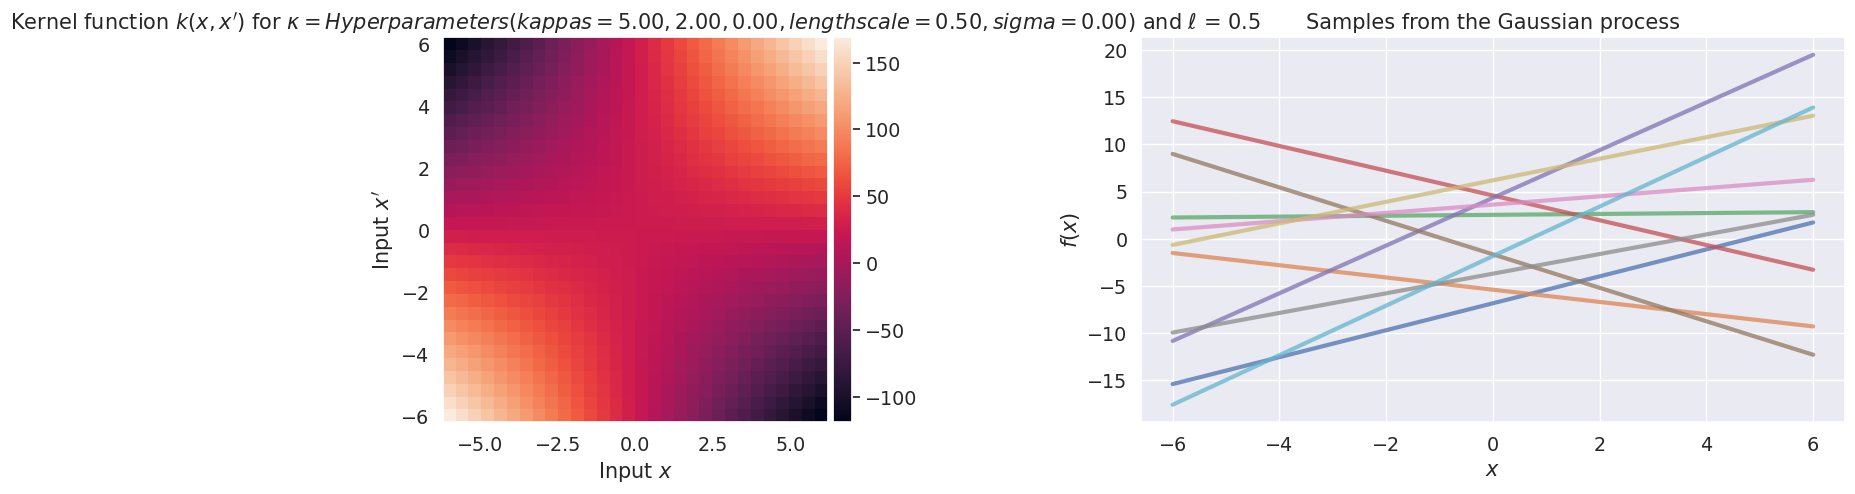

In [4]:
class StationaryIsotropicKernel(object):

    def __init__(self, kernel_fun):
        """
            the argument kernel_fun must be a function of two arguments kernel_fun(||tau||, hyperparameters), e.g. 
            squared_exponential = lambda tau, hyper: hyper.kappa**2*np.exp(-0.5*tau**2/hyper.lengthscale**2).
        """
        self.kernel_fun = kernel_fun

    def construct_kernel(self, X1, X2, hyperparameters, jitter=1e-8):
        """ compute and returns the NxM kernel matrix between the two sets of input X1 (shape NxD) and X2 (MxD) using the stationary and isotropic covariance function specified by self.kernel_fun
    
        arguments:
            X1              -- NxD matrix
            X2              -- MxD matrix or None
            hyperparameters -- Hyperparameter object compatible with self.kernel_fun function
            jitter          -- non-negative scalar
        
        returns
            K               -- NxM matrix    
        """

        # extract dimensions 
        N, M = X1.shape[0], X2.shape[0]
        K = X1[:,jnp.newaxis,:] - X2[jnp.newaxis,:,:]
        # Shape (N, D, M)
        K = jnp.linalg.norm(K, axis=-1)
        K = self.kernel_fun(K, hyperparameters) + jnp.eye(N,M)*jitter
        assert K.shape == (N, M), f"The shape of K appears wrong. Expected shape ({N}, {M}), but the actual shape was {K.shape}. Please check your code. "
        return K

# In this exercise our kernal is not isotropic.
class LinearKernel(object):

    def __init__(self, kernel_fun):
        self.kernel_fun = kernel_fun

    def construct_kernel(self, X1, X2, hyperparameters, jitter=1e-8):
        # extract dimensions 
        N, M = X1.shape[0], X2.shape[0]
        K = X1 @ X2.T + jnp.eye(N,M)*jitter
        K = self.kernel_fun(K, hyperparameters) 
        assert K.shape == (N, M), f"The shape of K appears wrong. Expected shape ({N}, {M}), but the actual shape was {K.shape}. Please check your code. "
        return K

def squared_exponential(tau, hyperparameters):
    return hyperparameters.kappa2**2*jnp.exp(-0.5*tau**2/hyperparameters.lengthscale**2)

def linear(K, hyperparameters):
    return hyperparameters.kappa1**2*K
        
# create an Nx1 vector of equidistant points in [-6, 6]
N = 30
X = jnp.linspace(-6, 6, N)[:, None]

# number of samples to be plotted
num_samples = 10

# specify random seed
key = random.PRNGKey(1)

# specify hyperparameters
hyper = Hyperparameters(kappa0=5, kappa1=2, kappa2=0, lengthscale=0.5)

# instantiate kernel object and construct kernel
kernel1 = StationaryIsotropicKernel(squared_exponential)
kernel2 = LinearKernel(linear)

K = kernel1.construct_kernel(X, X, hyper) + kernel2.construct_kernel(X, X, hyper) + hyper.kappa0**2

# plot
fig, ax = plt.subplots(1, 2, figsize=(20, 5))

im = ax[0].pcolormesh(X.flatten(), X.flatten(), K, shading='auto')
ax[0].set(xlabel='Input $x$', ylabel="Input $x'$", title=f"Kernel function $k(x, x')$ for $\\kappa = {hyper.__repr__()}$ and $\\ell$ = {hyper.lengthscale:2.1f}")
ax[0].grid(False)
ax[0].set_aspect('equal')
add_colorbar(im, fig, ax[0])

m = jnp.zeros(len(X))
f_samples = generate_samples(key, m, K, num_samples=num_samples, jitter=1e-8)
ax[1].plot(X, f_samples, alpha=0.75, linewidth=3);
ax[1].grid(True)
ax[1].set(xlabel='$x$', ylabel='$f(x)$', title='Samples from the Gaussian process');
plt.savefig("gp7_1.png")


# Part 2

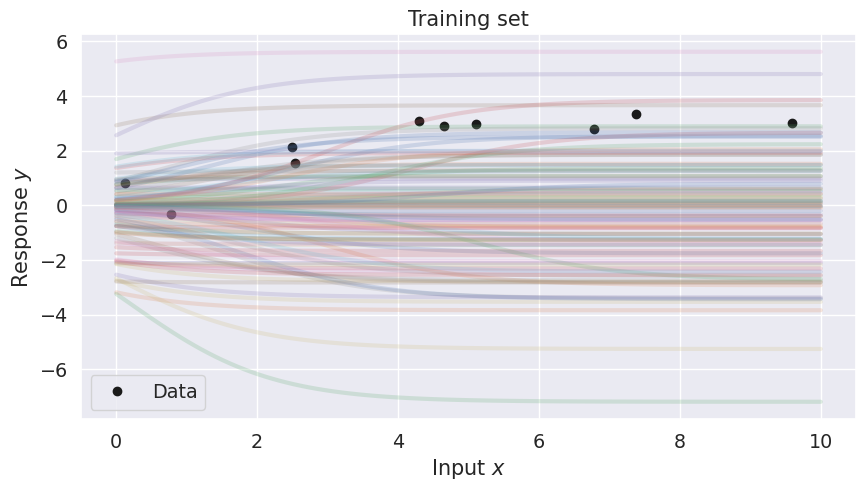

In [5]:
X = jnp.array([9.589, 7.375, 4.647, 2.501, 2.538, 6.783, 4.294, 5.111, 0.130, 0.783])
y = jnp.array([3.032, 3.349, 2.906, 2.126, 1.538, 2.787, 3.078, 2.993, 0.828, -0.331])
N = len(X)
sigmoid = lambda x: 1./(1 + jnp.exp(-x))

# for predictions
Xstar = jnp.linspace(0, 10, 100)[:, None]

def plot_data(ax, X, y, title):
    ax.plot(X, y, 'k.', markersize=12, label='Data')
    ax.grid(True)
    ax.set_xlabel('Input $x$')
    ax.set_ylabel('Response $y$')
    ax.legend()
    ax.set_title(title)

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
plot_data(ax, X, y, title='Training set')

# Generate model samples
num_samples = 100
tau = 2
beta = 4
D = 2
W = random.normal(key, shape=(D, num_samples)) * tau;
f = lambda x: W[None,1] * sigmoid(x + W[None,0]) 
f_star = f(Xstar)
ax.plot(Xstar, f_star, alpha=0.2, linewidth=3);

#f_map = lambda x: 3 * sigmoid(x -2)
#ax.plot(Xstar, f_map(Xstar), alpha=1, linewidth=3);
plt.savefig("log_reg_1.png")

# The sigmoid transformation is non linear and so the results for linear gaussian systems are not applicable.


In [6]:
from scipy.stats import multivariate_normal as mvn
from scipy.stats import beta as beta_dist
from scipy.stats import binom as binom_dist
from scipy.stats import norm as norm_dist

# helper functions implementing the pdf of a normal distribution
log_npdf = lambda x, m, v: -(x-m)**2/(2*v) - 0.5*jnp.log(2*jnp.pi*v)
npdf = lambda x, m, v: jnp.exp(log_npdf(x, m, v))

class LogisticRegression(object):

    def __init__(self, X, y, tau=2, beta=4):
        
        # store data and hyperparameters
        self.X = X
        self.y = y
        self.tau = tau
        self.beta = beta

        # store number of training data and number of features
        self.N, self.D = len(X), 2
        
        # get MAP by optimization
        self.w_MAP = self.get_MAP()
        
    def predict(self, X, w):
        """ evaluates sigma(f(X)) """
        # w (M, 2) remember to transpose before
        # X (N, D)
        # N is number of w samples. B is batch dimension
        return w[:,1,None] * sigmoid(X[None,:] + w[:,0,None]) # (M, N)

    def s(self, X, w):
        """ evaluates sigma(f(X)) """
        # w (M, 2) remember to transpose before
        # X (N, D)
        # N is number of w samples. B is batch dimension
        return sigmoid(X[None,:] + w[:,0,None]) # (M, N)

    def log_joint(self, w):
        """
            evaluates log joint, i.e. log p(y, w), for each row in w.
            w is expected to be of shape [M, D], where D is the number of parameters in the model and M is the number of points to evaluated
        """
        p = self.predict(self.X, w)
        log_prior = jnp.sum(log_npdf(w, 0, self.tau**2), axis=1)  # tau is std dev, so variance = tau**2
        log_lik = log_npdf(y,p, 1./self.beta)
        log_joint = log_prior + log_lik.sum(axis=1) # shape M

        return log_joint
    
    def hessian(self, w):
        """ Returns hessian of log joint evaluated at w 
            Input:   w       (shape: [1, D])
            Returns: H       (shape: [D, D])            """

        s = self.s(self.X, w)
        ss = s*(1-s)
        sss = (1-2*s)*ss

        H = np.zeros((2,2))
        H[0,0] = (-self.beta * jnp.sum((- self.y * w[0,1] * sss + w[0,1]**2 * (s*sss + ss*ss)), axis=1, keepdims=True)).item()
        H[1,1] = (-self.beta * jnp.sum(s**2, axis=1, keepdims=True)).item()
        H[0,1] = (-self.beta * jnp.sum((- self.y * ss + 2*w[0,1]*s*ss), axis=1, keepdims=True)).item()
        H[1,0] = (-self.beta * jnp.sum((- self.y * ss + 2*w[0,1]*s*ss), axis=1, keepdims=True)).item()
        H += - (self.tau**-2) * jnp.eye(2)
        H = jnp.asarray(H)
        assert H.shape == (self.D, self.D), f"The shape of the Hessians appears to be wrong. Expected shape ({self.D}, {self.D}), but received {H.shape}. Check your implementation"
        return H

    def grad(self, w):
        """ Returns gradient of log joint evaluated at w 
            Input:   w          (shape: [1, D])
            Returns: grad       (shape: [1, D])            """
        s = self.s(self.X, w) # (1, N)
        grad_prior = -w/(self.tau**2)
        grad_lik = - self.beta * jnp.sum((w[:,1] * s - self.y) * jnp.array([w[:,1] * s * (1-s), s]).squeeze(), axis=1, keepdims=True) 
        grad = grad_prior + grad_lik.T
        assert grad.shape == (1, 2), f"The shape of the gradient appears to be wrong. Expected shape (1, {2}), but received {grad.shape}. Check your implementation"
        return grad
  
    def get_MAP(self):
        """ returns MAP estimate obtained by maximizing the log joint """
        init_w = jnp.zeros(self.D)
        results = minimize(lambda x: -self.log_joint(x[None, :]), jac=lambda x: -self.grad(x[None, :]).flatten(), x0=init_w)
        if not results.success:
            print(results)
            raise ValueError('Optimization failed')
        
        w_MAP = results.x 
        return w_MAP


In [7]:
class Grid2D(object):
    """ helper class for evaluating the function func on the grid defined by (dim1, dim2)"""

    def __init__(self, dim1, dim2, func, name="Grid2D"):
        self.dim1 = dim1
        self.dim2 = dim2
        self.grid_size = (len(self.dim1), len(self.dim2))
        self.dim1_grid, self.dim2_grid = jnp.meshgrid(dim1, dim2, indexing='ij')
        self.func = func
        self.name = name
        
        # evaluate function on each grid point
        params_flat= jnp.column_stack((self.dim1_grid.flatten(), self.dim2_grid.flatten()))
        self.values = self.func(params_flat).squeeze().reshape(self.grid_size)

    def plot_contours(self, ax, color='b', num_contours=10, f=lambda x: x, alpha=1.0, title=None, label=None):
        out = ax.contour(self.dim1, self.dim2, (self.values).T, num_contours, colors=color, alpha=alpha)
        if label is not None:
            ax.plot([], [], color=color, label=label)
        ax.set(xlabel='$w_1$', ylabel='$w_2$')
        ax.set_title(self.name, fontweight='bold')
        return out

    def plot_heatmap(self, ax, f=lambda x: x, clim=[0, 1], colorbar=False):
        img = ax.pcolormesh(self.dim1, self.dim2, f(self.values).T, cmap=plt.cm.RdBu_r, clim=clim)
        ax.set(xlabel='$w_1$', ylabel='$w_2$')
        ax.set_title(self.name, fontweight='bold')
        if colorbar:
            add_colorbar(img, ax.get_figure(), ax)

[-130.94934095]
[-61.48913429 -61.48913429 -61.48913429]
[[-0.49710032 51.12425199]]
[[ -0.33679124  -1.48930995]
 [ -1.48930995 -36.92190935]]


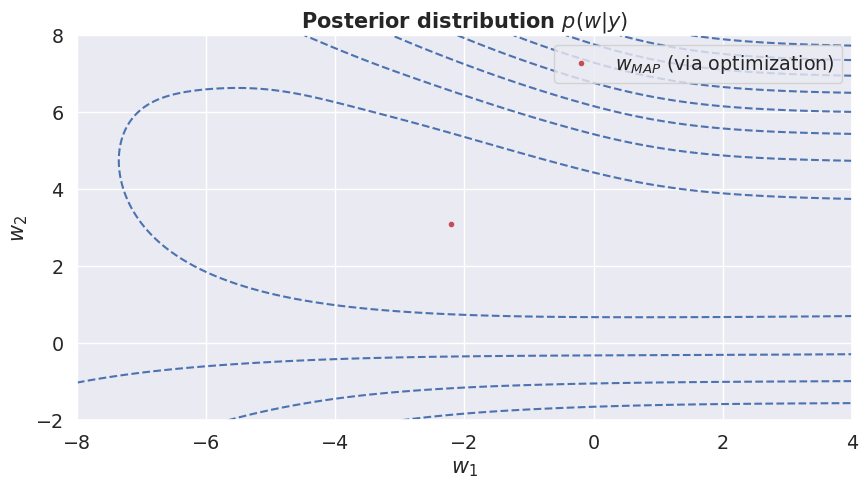

In [8]:
model = LogisticRegression(X, y)

print(model.log_joint(w=jnp.array([[0,0]])))
print(model.log_joint(w=jnp.ones((3,2))))
print(model.grad(w=jnp.array([[1,1]])))
print(model.hessian(w=jnp.array([[1,1]])))


# prep grid
dim1, dim2 = jnp.linspace(-8, 4, 150), jnp.linspace(-2, 8, 150)
grid_log_joint = Grid2D(dim1, dim2, model.log_joint, name='Posterior distribution $p(w|y)$')
# grid_predictions = Grid2D(dim1, dim2, pred_MAP, name='$p(y^*=1|y, w_{MAP})$')

# plot
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
grid_log_joint.plot_contours(ax, f=jnp.exp,)
ax.plot(model.w_MAP[0], model.w_MAP[1], 'r.', label='$w_{MAP}$ (via optimization)')
ax.legend()
plt.plot
# ax.plot(model.w_MAP[0], model.w_MAP[1], 'r.', label='$w_{MAP}$ (via optimization)')
ax.legend()


[-10.4096224]


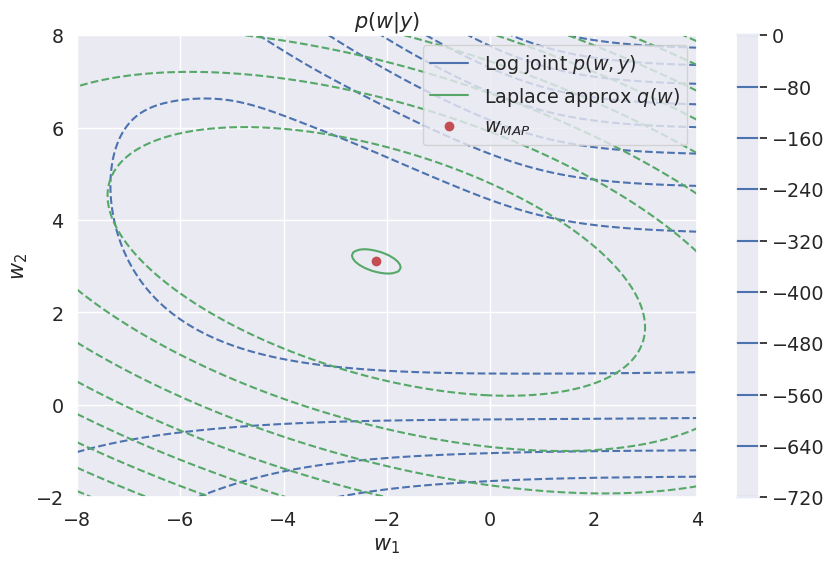

In [9]:
class LaplaceApproximation(object):

    def __init__(self, model: LogisticRegression):
        """ implements a laplace approximain q(w) = N(m, S), where m is the posterior mean and S is the posterior covariance """

        # store model
        self.model = model

        # implement Laplace approximation
        self.posterior_mean = self.model.get_MAP()
        self.posterior_hessian = self.model.hessian(self.posterior_mean[None, :])
        self.posterior_cov = - jnp.linalg.inv(self.model.hessian(self.posterior_mean[None, :])) # The negative inverse of the hessian.

        # sanity check for dimensions
        assert self.posterior_mean.shape == (model.D,), f"The shape of the posterior mean appears wrong. Check your implementaion."
        assert self.posterior_hessian.shape == (model.D, model.D), f"The shape of the posterior Hessian appears wrong. Check your implementaion."
        assert self.posterior_cov.shape == (model.D, model.D), f"The shape of the posterior covariance appears wrong. Check your implementaion."

    def log_pdf(self, w):
        """ evaluate approximate posterior density at w """
        return mvn.logpdf(w, self.posterior_mean.ravel(), self.posterior_cov)
    
    def posterior_samples(self, key, num_samples):
        """ generate samples from posterior distribution """
        return random.multivariate_normal(key, self.posterior_mean, self.posterior_cov, shape=(num_samples, ))

# prep model and approximation
model = LogisticRegression(X, y)
laplace = LaplaceApproximation(model)

# prep grid
dim1, dim2 = jnp.linspace(-4, 4, 100), jnp.linspace(-4, 4, 100)
dim1, dim2 = jnp.linspace(-8, 4, 150), jnp.linspace(-2, 8, 150)
grid_log_joint = Grid2D(dim1, dim2, model.log_joint, name='$p(w|y)$')
grid_laplace_log_joint = Grid2D(dim1, dim2, laplace.log_pdf, name='$p(w|y)$')

# plot
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
out = grid_log_joint.plot_contours(ax, label='Log joint $p(w, y)$', num_contours=10)
grid_laplace_log_joint.plot_contours(ax, color="g", label='Laplace approx $q(w)$', num_contours=10)
fig.colorbar(out, ax=ax)
# ax.plot(w_samples[:, 0], w_samples[:, 1], 'g.', label='Posterior samples')
ax.plot(model.w_MAP[0], model.w_MAP[1], 'ro', label='$w_{MAP}$')
ax.legend();
plt.savefig("2Dcontourplot")
print(model.log_joint(model.w_MAP[None,:]))

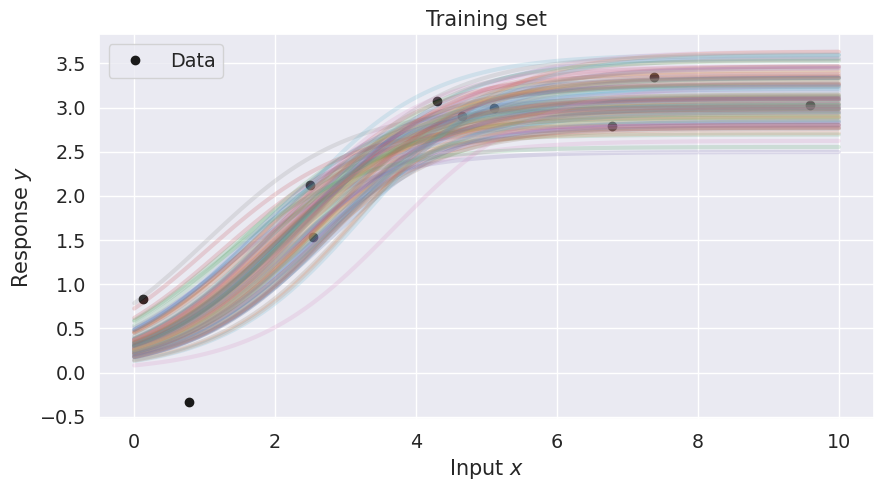

In [10]:
# generate samples from posterior
num_samples = 100
key = random.PRNGKey(1)
w_samples = laplace.posterior_samples(key, num_samples)

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
plot_data(ax, X, y, title='Training set')

# Generate model samples
f = lambda x: w_samples[None,:,1] * sigmoid(x + w_samples[None,:,0]) 
f_star = f(Xstar)
ax.plot(Xstar, f_star, alpha=0.2, linewidth=3);

#f_map = lambda x: 3 * sigmoid(x -2)
#ax.plot(Xstar, f_map(Xstar), alpha=1, linewidth=3);
plt.savefig("log_reg_lap.png")




In [11]:
num_samples = 1000000
w_samples = laplace.posterior_samples(key, num_samples)
f = lambda x: w_samples[None,:,1] * sigmoid(x + w_samples[None,:,0]) 
print(jnp.mean(f(8) > 3)) 

x = f(3.75).squeeze()
print(np.mean(x))
N = len(x)
print(np.sort(x)[int(N*0.025)])
print(np.sort(x)[int(N*0.975)])



0.661297
2.5282239385897984
2.1386866203103234
2.9009536769651993


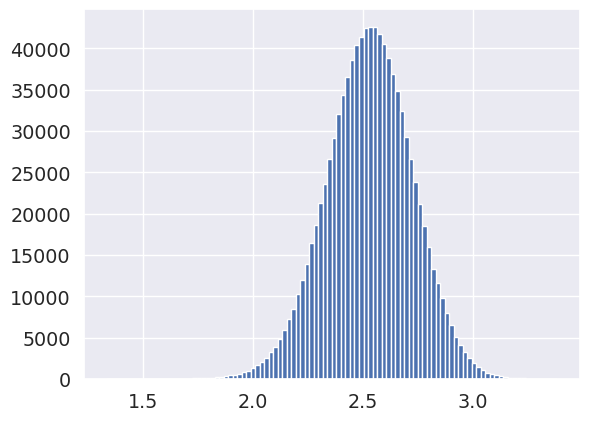

In [12]:
plt.hist(f(3.75).squeeze(), bins=100)
plt.savefig("lap_hist")